# WriteLens, Eksplorasi Data (EDA)

Notebook ini buat kenalan sama dua dataset yang bakal dipake: DAIGT v2 sama MAGE.
Tujuannya: pahamin isinya, cek distribusi label, lihat panjang teks, dan bersihin yang kotor sebelum masuk feature engineering.

Output:
- Cleaned dataset di `data/processed/`
- Plot buat slide PPT di `data/processed/plots/`


## Section 1. Setup

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

PLOTS_DIR = "../data/processed/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0E0E16',
    'axes.facecolor': '#14141E',
    'axes.edgecolor': '#2A2A3C',
    'axes.labelcolor': '#E8E8ED',
    'text.color': '#E8E8ED',
    'xtick.color': '#8888A0',
    'ytick.color': '#8888A0',
    'grid.color': '#1E1E2E',
    'font.family': 'sans-serif',
    'font.size': 11,
})

TEAL  = "#4ECDC4"
CORAL = "#F47C7C"
AMBER = "#F0C05A"
GREEN = "#5EE0A0"
MUTED = "#8888A0"

def savefig(name):
    plt.savefig(os.path.join(PLOTS_DIR, name), dpi=150, bbox_inches='tight', facecolor='#0E0E16')


## Section 2. Load Data

### DAIGT v2
Filenya di repo namanya `train_v2_drcat_02.csv` (dari Kaggle). Kolom `text` sama `label` udah sesuai konvensi kita (0 = human, 1 = AI), jadi nggak perlu rename.

In [149]:
daigt = pd.read_csv("../data/raw/train_v2_drcat_02.csv")
print("Shape:", daigt.shape)
print("Columns:", list(daigt.columns))
print(daigt.dtypes)
print("Jumlah null:", daigt.isnull().sum().sum())
daigt.head(3)


Shape: (44868, 5)
Columns: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven']
text             object
label             int64
prompt_name      object
source           object
RDizzl3_seven      bool
dtype: object
Jumlah null: 0


,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False


In [150]:
for c in daigt.columns:
    print(c, "->", daigt[c].nunique(), "unique")

print()
print("Label counts DAIGT:")
print(daigt['label'].value_counts())


text -> 44868 unique
label -> 2 unique
prompt_name -> 15 unique
source -> 17 unique
RDizzl3_seven -> 2 unique

Label counts DAIGT:
label
0    27371
1    17497
Name: count, dtype: int64


### MAGE
MAGE ada dua file (train + test), digabung dulu. Kolomnya namanya `src` bukan `source`, jadi di-rename. Label MAGE itu kebalikan: 0 = machine, 1 = human, jadi harus di-invert biar konsisten sama DAIGT (0 = human, 1 = AI).

In [151]:
mage_train = pd.read_csv("../data/raw/mage_train.csv")
mage_test  = pd.read_csv("../data/raw/mage_test.csv")
print("train:", mage_train.shape, " test:", mage_test.shape)

mage = pd.concat([mage_train, mage_test], ignore_index=True)
mage = mage.rename(columns={'src': 'source'})
print("MAGE gabung:", mage.shape)
print(mage.isnull().sum())

print("Sebelum invert:")
print(mage['label'].value_counts())

mage['label'] = 1 - mage['label']

print("Setelah invert (0=human, 1=AI):")
print(mage['label'].value_counts())
mage.head(3)


train: (319071, 3)  test: (60743, 3)
MAGE gabung: (379814, 3)
text      0
label     0
source    0
dtype: int64
Sebelum invert:
label
0    256231
1    123583
Name: count, dtype: int64
Setelah invert (0=human, 1=AI):
label
1    256231
0    123583
Name: count, dtype: int64


,text,label,source
0,White girls very rarely date Asian men. Even i...,0,cmv_human
1,I am a 23 year old male Indian American male. ...,0,cmv_human
2,"Take three people, Persons A, B, and C. They l...",0,cmv_human


### Verifikasi label MAGE
Karena label-nya barusan di-invert, mending dicek dulu. Source yang ada kata 'human'-nya harusnya berlabel 0 sekarang.

In [152]:
cek = mage[mage['source'].str.contains('human', na=False)].head(5)
print(cek[['source', 'label']])
print()
print("Unique label di source ber-'human':", cek['label'].unique())


      source  label
0  cmv_human      0
1  cmv_human      0
2  cmv_human      0
3  cmv_human      0
4  cmv_human      0

Unique label di source ber-'human': [0]


## Section 3. Statistik Dasar

Tambah kolom panjang teks: word count, char count, sentence count, rata-rata panjang kata.

In [153]:
daigt['word_count']     = daigt['text'].apply(lambda x: len(str(x).split()))
daigt['char_count']     = daigt['text'].apply(lambda x: len(str(x)))
daigt['sentence_count'] = daigt['text'].apply(lambda x: len([s for s in re.split(r'[.!?]+', str(x)) if s.strip()]))
daigt['avg_word_length'] = daigt['text'].apply(
    lambda x: np.mean([len(w) for w in re.findall(r"[A-Za-z']+", str(x))]) if re.findall(r"[A-Za-z']+", str(x)) else 0
)

mage['word_count']     = mage['text'].apply(lambda x: len(str(x).split()))
mage['char_count']     = mage['text'].apply(lambda x: len(str(x)))
mage['sentence_count'] = mage['text'].apply(lambda x: len([s for s in re.split(r'[.!?]+', str(x)) if s.strip()]))
mage['avg_word_length'] = mage['text'].apply(
    lambda x: np.mean([len(w) for w in re.findall(r"[A-Za-z']+", str(x))]) if re.findall(r"[A-Za-z']+", str(x)) else 0
)

daigt[['word_count','sentence_count','avg_word_length']].describe()


,word_count,sentence_count,avg_word_length
count,44868.000000,44868.000000,44868.000000
mean,383.621334,20.248952,4.624942
std,164.926131,8.957018,0.451642
min,4.000000,1.000000,1.024096
25%,274.000000,14.000000,4.300965
50%,352.000000,19.000000,4.569836
75%,451.000000,25.000000,4.884235
max,1656.000000,135.000000,7.000000


Ringkasan per label, pake groupby aja biar simpel.

In [154]:
print("DAIGT v2")
print(daigt.groupby('label')[['word_count','sentence_count','avg_word_length','char_count']].describe().T)


DAIGT v2
label                             0             1
word_count      count  27371.000000  17497.000000
                mean     418.283146    329.398983
                std      189.285918     94.256529
                min      143.000000      4.000000
                25%      274.000000    274.000000
                50%      383.000000    328.000000
                75%      519.000000    386.000000
                max     1656.000000    818.000000
sentence_count  count  27371.000000  17497.000000
                mean      21.428921     18.403098
                std       10.072558      6.437283
                min        1.000000      1.000000
                25%       14.000000     14.000000
                50%       20.000000     18.000000
                75%       27.000000     22.000000
                max      135.000000     63.000000
avg_word_length count  27371.000000  17497.000000
                mean       4.427488      4.933824
                std        0.308070      

In [155]:
print("MAGE")
print(mage.groupby('label')[['word_count','sentence_count','avg_word_length','char_count']].describe().T)


MAGE
label                              0              1
word_count      count  123583.000000  256231.000000
                mean      198.370415     218.424301
                std       255.474201     237.979805
                min         6.000000       6.000000
                25%        61.000000      52.000000
                50%       121.000000     114.000000
                75%       228.000000     276.000000
                max     10129.000000    1770.000000
sentence_count  count  123583.000000  256231.000000
                mean       13.206234      14.076076
                std        18.683468      19.228515
                min         1.000000       1.000000
                25%         4.000000       3.000000
                50%         7.000000       6.000000
                75%        14.000000      15.000000
                max       618.000000     483.000000
avg_word_length count  123583.000000  256231.000000
                mean        4.583692       4.661686
       

## Section 4. Distribusi Label
Ini penting buat slide Dataset Description, nunjukin balance / imbalance class-nya.

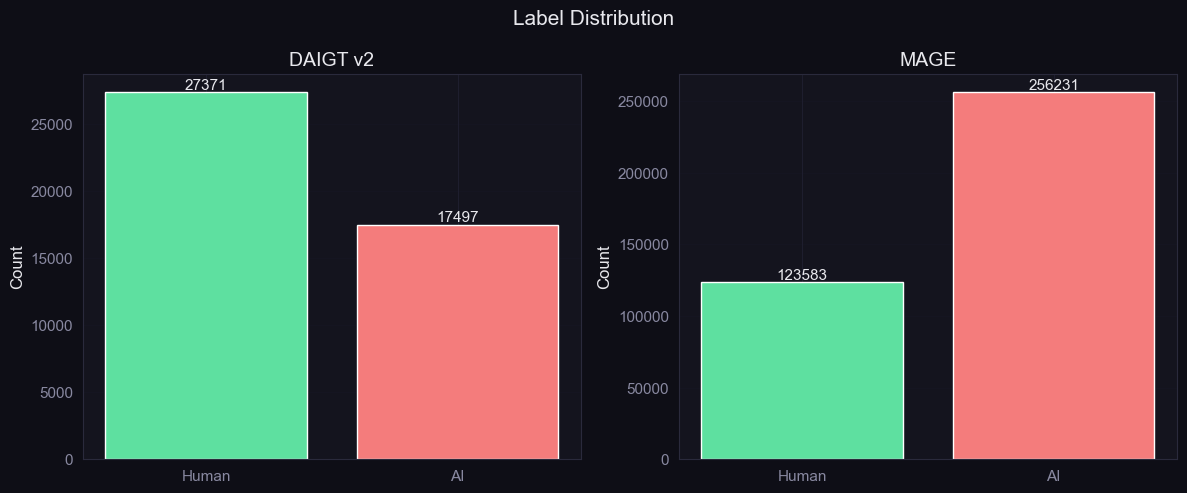

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts_daigt = daigt['label'].value_counts().sort_index()
axes[0].bar(['Human', 'AI'], [counts_daigt[0], counts_daigt[1]], color=[GREEN, CORAL])
axes[0].set_title("DAIGT v2")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', alpha=0.2)
for i, v in enumerate([counts_daigt[0], counts_daigt[1]]):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

counts_mage = mage['label'].value_counts().sort_index()
axes[1].bar(['Human', 'AI'], [counts_mage[0], counts_mage[1]], color=[GREEN, CORAL])
axes[1].set_title("MAGE")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y', alpha=0.2)
for i, v in enumerate([counts_mage[0], counts_mage[1]]):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

fig.suptitle("Label Distribution", fontsize=15)
plt.tight_layout()
savefig("label_distribution.png")
plt.show()


## Section 5. Panjang Teks

Histogram word count. Human (hijau) vs AI (coral), garis putus-putus = median.

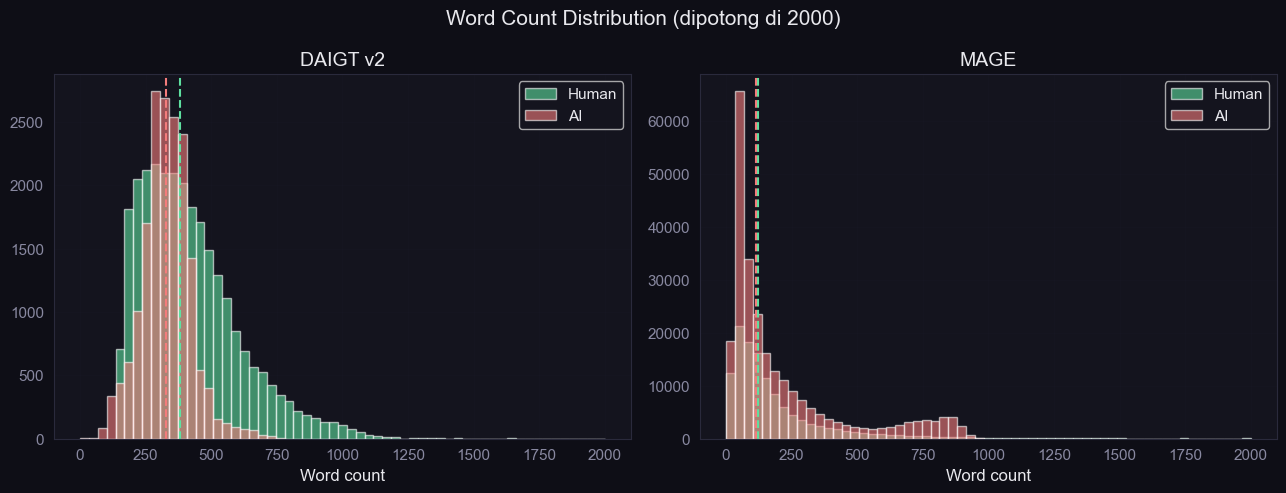

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
XCLIP = 2000

for ax, df, title in [(axes[0], daigt, "DAIGT v2"), (axes[1], mage, "MAGE")]:
    h = df.loc[df['label']==0, 'word_count']
    a = df.loc[df['label']==1, 'word_count']
    bins = np.linspace(0, XCLIP, 60)
    ax.hist(h.clip(upper=XCLIP), bins=bins, color=GREEN, alpha=0.6, label='Human')
    ax.hist(a.clip(upper=XCLIP), bins=bins, color=CORAL, alpha=0.6, label='AI')
    ax.axvline(h.median(), color=GREEN, ls='--')
    ax.axvline(a.median(), color=CORAL, ls='--')
    ax.set_title(title)
    ax.set_xlabel("Word count")
    ax.legend()
    ax.grid(alpha=0.15)

fig.suptitle("Word Count Distribution (dipotong di 2000)", fontsize=15)
plt.tight_layout()
savefig("word_count_distribution.png")
plt.show()


Box plot, biar spread sama outlier-nya lebih kelihatan.

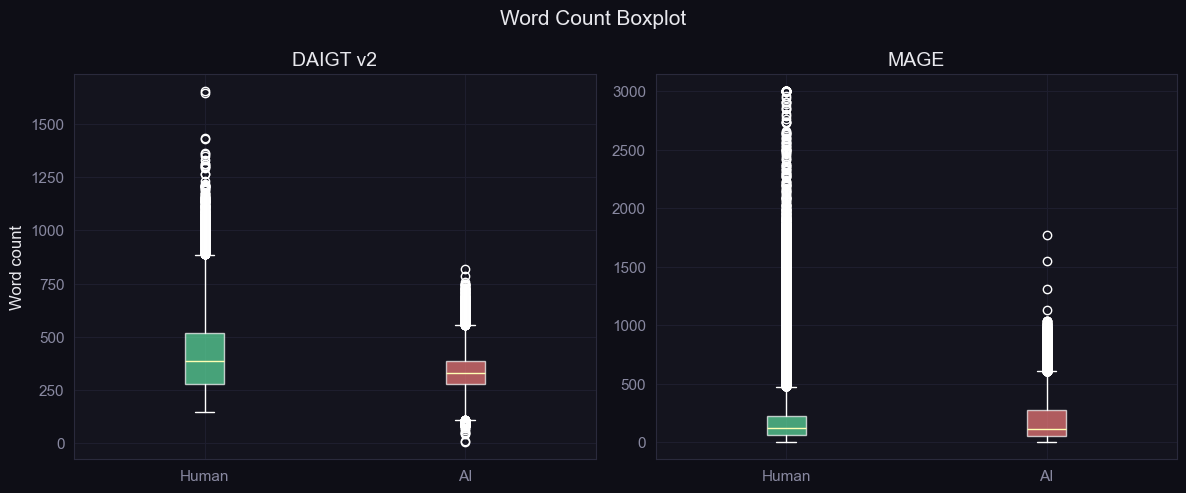

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

d1 = [daigt.loc[daigt['label']==0,'word_count'].clip(upper=3000),
      daigt.loc[daigt['label']==1,'word_count'].clip(upper=3000)]
bp1 = axes[0].boxplot(d1, labels=['Human','AI'], patch_artist=True)
for patch, c in zip(bp1['boxes'], [GREEN, CORAL]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_title("DAIGT v2")
axes[0].set_ylabel("Word count")

d2 = [mage.loc[mage['label']==0,'word_count'].clip(upper=3000),
      mage.loc[mage['label']==1,'word_count'].clip(upper=3000)]
bp2 = axes[1].boxplot(d2, labels=['Human','AI'], patch_artist=True)
for patch, c in zip(bp2['boxes'], [GREEN, CORAL]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title("MAGE")

fig.suptitle("Word Count Boxplot", fontsize=15)
plt.tight_layout()
savefig("word_count_boxplot.png")
plt.show()


Sama tapi buat sentence count.

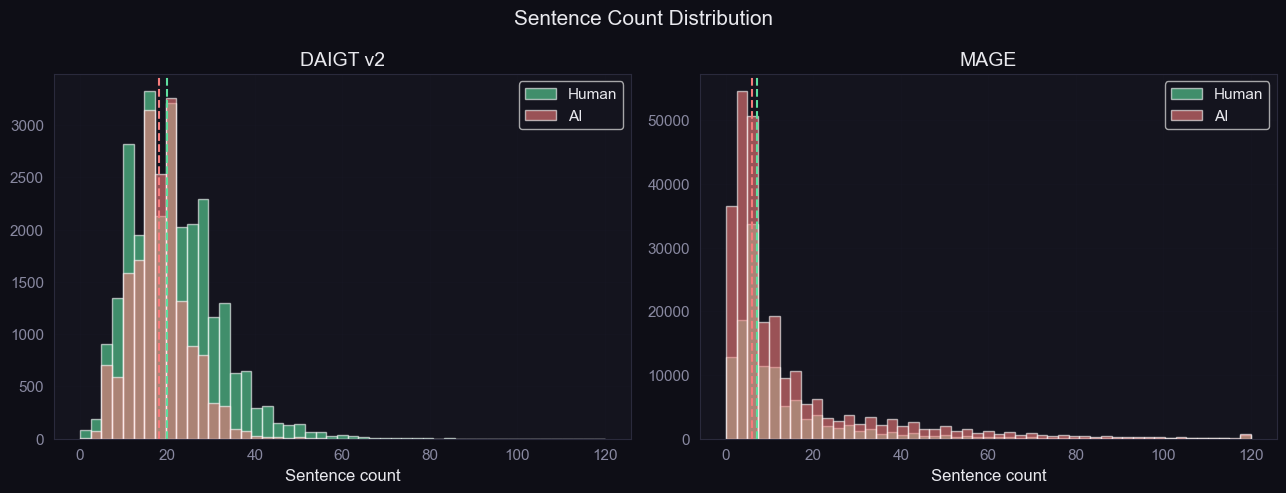

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
XCLIP = 120

for ax, df, title in [(axes[0], daigt, "DAIGT v2"), (axes[1], mage, "MAGE")]:
    h = df.loc[df['label']==0, 'sentence_count']
    a = df.loc[df['label']==1, 'sentence_count']
    bins = np.linspace(0, XCLIP, 50)
    ax.hist(h.clip(upper=XCLIP), bins=bins, color=GREEN, alpha=0.6, label='Human')
    ax.hist(a.clip(upper=XCLIP), bins=bins, color=CORAL, alpha=0.6, label='AI')
    ax.axvline(h.median(), color=GREEN, ls='--')
    ax.axvline(a.median(), color=CORAL, ls='--')
    ax.set_title(title)
    ax.set_xlabel("Sentence count")
    ax.legend()
    ax.grid(alpha=0.15)

fig.suptitle("Sentence Count Distribution", fontsize=15)
plt.tight_layout()
savefig("sentence_count_distribution.png")
plt.show()


## Section 6. Source MAGE
MAGE ngumpulin teks dari macem-macem tempat (Reddit, Yelp, QA, dll) dan dari macem-macem LLM. Bagian ini buat lihat variasinya.

Total unique source: 338
source
yelp_human                                 34479
eli5_human                                 19862
squad_human                                18328
wp_human                                    9455
xsum_human                                  7991
sci_gen_human                               6974
cmv_human                                   6626
roct_human                                  6562
hswag_human                                 6421
tldr_human                                  5361
roct_machine_topical_gpt-3.5-trubo           900
roct_machine_specified_gpt-3.5-trubo         900
wp_machine_specified_text-davinci-003        900
roct_machine_topical_text-davinci-002        900
wp_machine_specified_gpt-3.5-trubo           900
wp_machine_topical_text-davinci-003          900
roct_machine_specified_text-davinci-003      900
xsum_machine_continuation_t0_3b              900
xsum_machine_topical_gpt-3.5-trubo           900
xsum_machine_continuation_gpt-3.5-tru

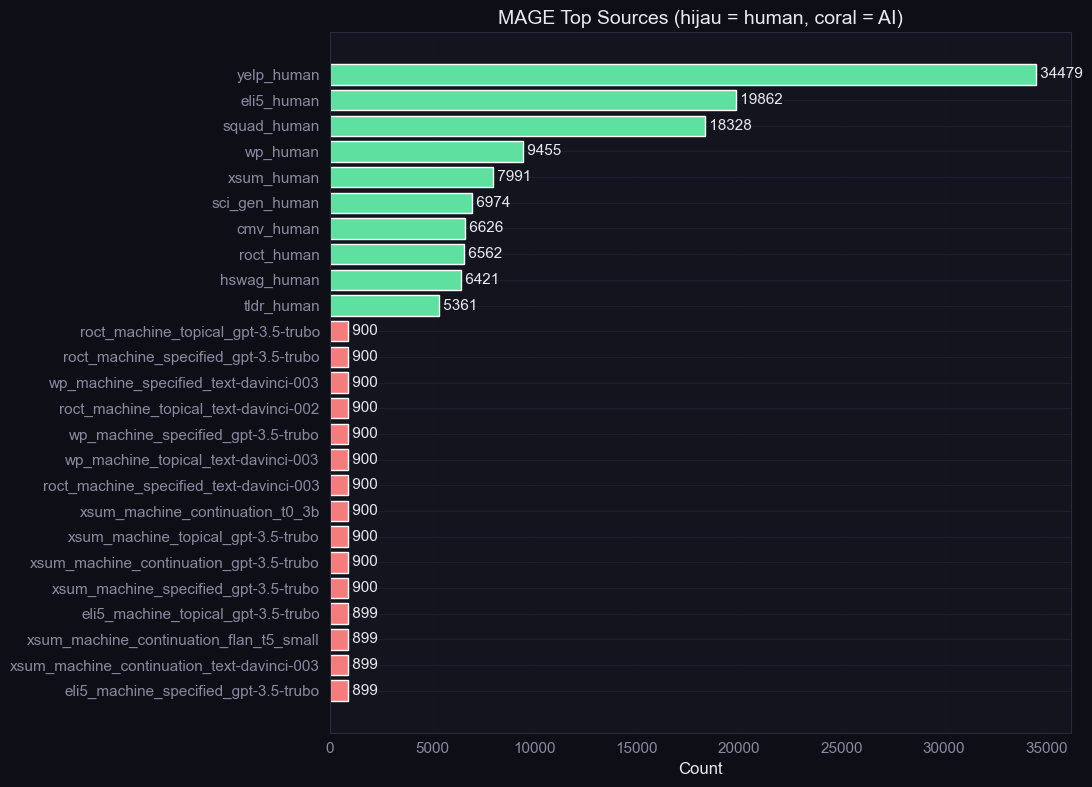

In [160]:
src_counts = mage['source'].value_counts()
print("Total unique source:", len(src_counts))
print(src_counts.head(20))

def is_human_src(s):
    return 'human' in str(s).lower()

top_n = min(25, len(src_counts))
top = src_counts.head(top_n).iloc[::-1]
colors = [GREEN if is_human_src(s) else CORAL for s in top.index]

fig, ax = plt.subplots(figsize=(11, max(6, top_n*0.32)))
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("Count")
ax.set_title("MAGE Top Sources (hijau = human, coral = AI)")
ax.grid(axis='x', alpha=0.15)
for i, v in enumerate(top.values):
    ax.text(v, i, " " + str(v), va='center')
plt.tight_layout()
savefig("mage_source_distribution.png")
plt.show()


Word count per source. Apakah model LLM tertentu cenderung nulis lebih panjang/pendek?

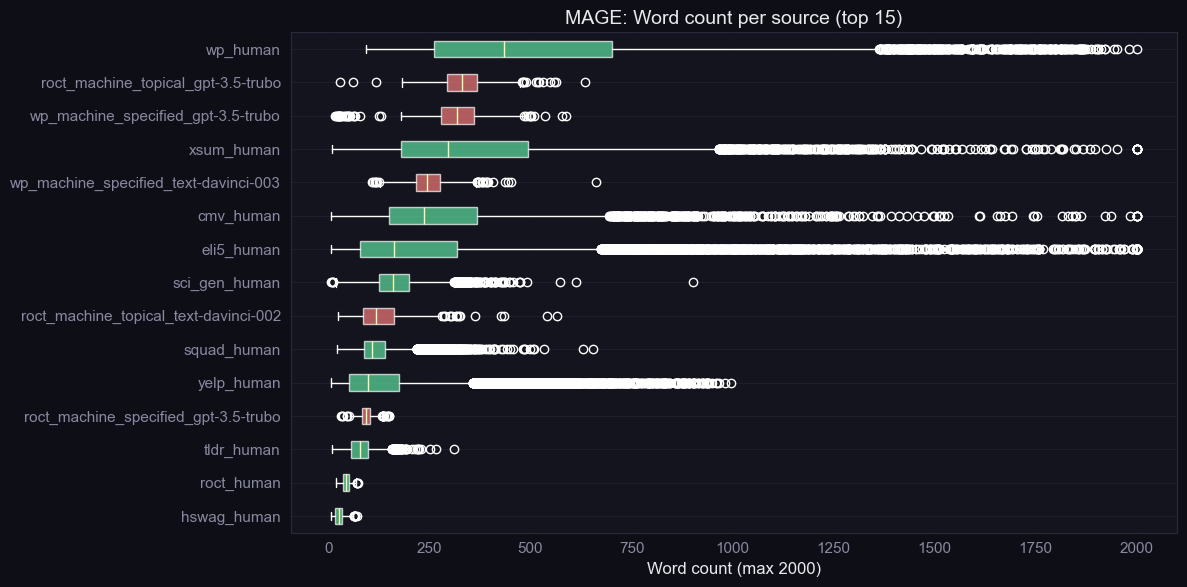

In [161]:
top_sources = mage['source'].value_counts().head(15).index.tolist()
sub = mage[mage['source'].isin(top_sources)].copy()
sub['wc_clip'] = sub['word_count'].clip(upper=2000)

order = sub.groupby('source')['wc_clip'].median().sort_values().index.tolist()
data = [sub.loc[sub['source']==s, 'wc_clip'].values for s in order]
colors = [GREEN if is_human_src(s) else CORAL for s in order]

fig, ax = plt.subplots(figsize=(12, max(6, len(order)*0.4)))
bp = ax.boxplot(data, labels=order, vert=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xlabel("Word count (max 2000)")
ax.set_title("MAGE: Word count per source (top 15)")
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
savefig("mage_wordcount_by_source.png")
plt.show()


## Section 7. Contoh Teks
Buka beberapa sample biar bisa lihat langsung beda gaya tulisan human vs AI.

In [162]:
human_samp = daigt[daigt['label']==0].sample(3, random_state=42)
ai_samp    = daigt[daigt['label']==1].sample(3, random_state=42)

for i, (_, row) in enumerate(human_samp.iterrows(), 1):
    text = str(row['text'])[:500].replace('\n', ' ')
    print("=== HUMAN", i, "===")
    print(text + ("..." if len(str(row['text'])) > 500 else ""))
    print("Words:", row['word_count'], "Sentences:", row['sentence_count'])
    print()

for i, (_, row) in enumerate(ai_samp.iterrows(), 1):
    text = str(row['text'])[:500].replace('\n', ' ')
    print("=== AI", i, "===")
    print(text + ("..." if len(str(row['text'])) > 500 else ""))
    print("Words:", row['word_count'], "Sentences:", row['sentence_count'])
    print()


=== HUMAN 1 ===
Are you looking for something to do in your life? If your are then you should join the Seagoing Cowboy program. At first you will have a meloncoly demeanor,but you will get use to traveling and being away from home. The animals you take care of will give you an exubernt feeling. Also, you will be able to vist many different places around the world. You will have alot of fun with to people you meet on the ship. We have alot of things you can do when you get off the ship like you can have fun by d...
Words: 279 Sentences: 22

=== HUMAN 2 ===
Dear principal,  It has come to attention that you are considering changing school policy so that students may not participate in sport of other activities unless they have at least a grade B average. Of course, many students have a C average. It is my opinion that students should be allowed to play sports even thought they have a C average. I have many reasons for this, extra curricular activities are to be enjoyed and anyone should 

## Section 8. Cek Kualitas Data

Duplikat dulu.

In [163]:
daigt_dupes = daigt['text'].duplicated().sum()
mage_dupes  = mage['text'].duplicated().sum()
print("DAIGT duplikat:", daigt_dupes)
print("MAGE duplikat:", mage_dupes)


DAIGT duplikat: 0
MAGE duplikat: 762


### Cek teks pendek/panjang
Teks di bawah 20 kata terlalu pendek buat analisis, yang di atas 5000 kata outlier. Kita filter dua-duanya.

In [164]:
short_daigt = (daigt['word_count'] < 20).sum()
long_daigt  = (daigt['word_count'] > 5000).sum()
short_mage  = (mage['word_count']  < 20).sum()
long_mage   = (mage['word_count']  > 5000).sum()

print("DAIGT pendek:", short_daigt, " panjang:", long_daigt)
print("MAGE pendek:", short_mage, " panjang:", long_mage)


DAIGT pendek: 2  panjang: 0
MAGE pendek: 7057  panjang: 14


Cek null / string kosong.

In [165]:
print("DAIGT null:", daigt['text'].isnull().sum(),
      " kosong:", (daigt['text'].fillna('').str.strip().str.len()==0).sum())
print("MAGE null:", mage['text'].isnull().sum(),
      " kosong:", (mage['text'].fillna('').str.strip().str.len()==0).sum())


DAIGT null: 0  kosong: 0
MAGE null: 0  kosong: 0


Ringkas semua angka di atas.

In [166]:
print("DAIGT v2")
print("Total:", len(daigt))
print("Duplikat:", daigt_dupes)
print("Terlalu pendek:", short_daigt)
print("Terlalu panjang:", long_daigt)
print()
print("MAGE")
print("Total:", len(mage))
print("Duplikat:", mage_dupes)
print("Terlalu pendek:", short_mage)
print("Terlalu panjang:", long_mage)


DAIGT v2
Total: 44868
Duplikat: 0
Terlalu pendek: 2
Terlalu panjang: 0

MAGE
Total: 379814
Duplikat: 762
Terlalu pendek: 7057
Terlalu panjang: 14


## Section 9. Cleaning
Langkah-langkahnya: buang null/kosong, buang duplikat, filter panjang teks ke rentang 20 sampai 5000 kata. Dipakai ke dua dataset, jadi dibungkus function.

In [167]:
def clean_dataset(df, name):
    n0 = len(df)
    df = df.dropna(subset=['text']).copy()
    df = df[df['text'].str.strip().str.len() > 0]
    df = df.drop_duplicates(subset=['text'])
    df = df[df['word_count'] >= 20]
    df = df[df['word_count'] <= 5000]
    n1 = len(df)
    print(name, ":", n0, "->", n1, " (buang", n0-n1, ")")
    return df.reset_index(drop=True)

daigt_clean = clean_dataset(daigt, "DAIGT v2")
mage_clean  = clean_dataset(mage,  "MAGE")


DAIGT v2 : 44868 -> 44866  (buang 2 )
MAGE : 379814 -> 371981  (buang 7833 )


### Cross-dataset duplicate
Gabungin dulu sementara, terus cek apakah ada teks yang muncul di kedua dataset.

In [168]:
tmp = pd.concat([daigt_clean[['text']], mage_clean[['text']]], ignore_index=True)
combined_dupes = tmp['text'].duplicated().sum()
internal = daigt_clean['text'].duplicated().sum() + mage_clean['text'].duplicated().sum()
cross = combined_dupes - internal
print("Total duplikat di gabungan:", combined_dupes)
print("Duplikat dalam masing-masing:", internal)
print("Duplikat antar dataset:", cross)


Total duplikat di gabungan: 0
Duplikat dalam masing-masing: 0
Duplikat antar dataset: 0


Plot ulang label distribution setelah cleaning, biar yakin balance-nya nggak berubah drastis.

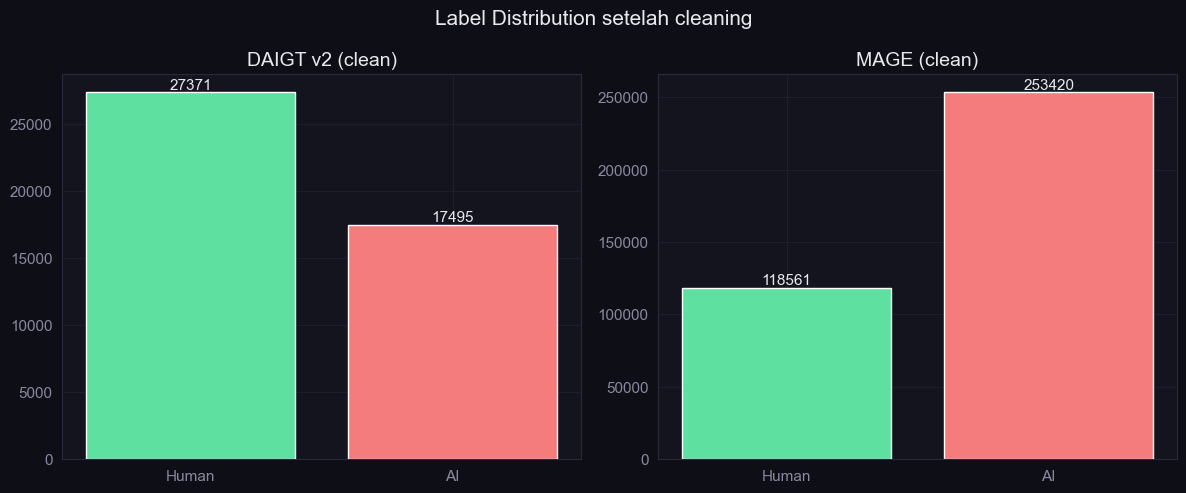

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

c1 = daigt_clean['label'].value_counts().sort_index()
axes[0].bar(['Human','AI'], [c1[0], c1[1]], color=[GREEN, CORAL])
axes[0].set_title("DAIGT v2 (clean)")
for i, v in enumerate([c1[0], c1[1]]):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

c2 = mage_clean['label'].value_counts().sort_index()
axes[1].bar(['Human','AI'], [c2[0], c2[1]], color=[GREEN, CORAL])
axes[1].set_title("MAGE (clean)")
for i, v in enumerate([c2[0], c2[1]]):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

fig.suptitle("Label Distribution setelah cleaning", fontsize=15)
plt.tight_layout()
savefig("label_distribution_clean.png")
plt.show()


## Section 10. Perbandingan Dataset

In [170]:
combined = pd.concat([daigt_clean, mage_clean], ignore_index=True)

rows = []
for name, df in [("DAIGT v2", daigt_clean), ("MAGE", mage_clean), ("Combined", combined)]:
    total = len(df)
    h = int((df['label']==0).sum())
    a = int((df['label']==1).sum())
    rows.append({
        "Dataset": name,
        "Total": total,
        "Human": h,
        "AI": a,
        "Balance H/AI": "{:.1f}% / {:.1f}%".format(h/total*100, a/total*100),
        "Median words": int(df['word_count'].median()),
    })

comp = pd.DataFrame(rows).set_index("Dataset")
print(comp)


           Total   Human      AI   Balance H/AI  Median words
Dataset                                                      
DAIGT v2   44866   27371   17495  61.0% / 39.0%           352
MAGE      371981  118561  253420  31.9% / 68.1%           119
Combined  416847  145932  270915  35.0% / 65.0%           141


### Class imbalance
Di gabungan, ratio human:AI ternyata cukup miring (sekitar 35% human, 65% AI). Ini perlu di-flag dan ditanganin di tahap training nanti. Beberapa opsi:
- Stratified split waktu train/val/test
- `class_weight='balanced'` di model sklearn
- Undersample AI biar seimbang sama human
- Atau pake DAIGT v2 sendirian dulu yang lebih balanced

Keputusan finalnya nanti pas notebook training, tapi disebut di sini biar kebawa konteksnya.

In [171]:
h = int((combined['label']==0).sum())
a = int((combined['label']==1).sum())
total = h + a
print("Combined human:", h, "({:.1f}%)".format(h/total*100))
print("Combined AI:   ", a, "({:.1f}%)".format(a/total*100))
print("Ratio AI/Human: {:.2f}".format(a/h))


Combined human: 145932 (35.0%)
Combined AI:    270915 (65.0%)
Ratio AI/Human: 1.86


### Domain mismatch
DAIGT v2 isinya essay mahasiswa (formal, lebih panjang). MAGE isinya teks Reddit, Yelp, QA (lebih pendek, informal). Median word count-nya beda jauh, jadi gabungin mentah-mentah mungkin bikin model belajar 'pendek = MAGE = mostly AI' bukan ciri AI yang sebenernya.

In [172]:
print("Median word count per dataset:")
print("  DAIGT human:", int(daigt_clean.loc[daigt_clean['label']==0,'word_count'].median()))
print("  DAIGT AI:   ", int(daigt_clean.loc[daigt_clean['label']==1,'word_count'].median()))
print("  MAGE human: ", int(mage_clean.loc[mage_clean['label']==0,'word_count'].median()))
print("  MAGE AI:    ", int(mage_clean.loc[mage_clean['label']==1,'word_count'].median()))
print()
print("Pertimbangan: kalau combining langsung, sinyalnya bisa ke-bias sama domain bukan ke gaya AI vs human.")
print("Opsi yang masuk akal: DAIGT v2 sebagai primary, MAGE buat augmentasi dengan sampling proporsional.")


Median word count per dataset:
  DAIGT human: 383
  DAIGT AI:    328
  MAGE human:  125
  MAGE AI:     116

Pertimbangan: kalau combining langsung, sinyalnya bisa ke-bias sama domain bukan ke gaya AI vs human.
Opsi yang masuk akal: DAIGT v2 sebagai primary, MAGE buat augmentasi dengan sampling proporsional.


Histogram gabungan, sekedar lihat overall picture.

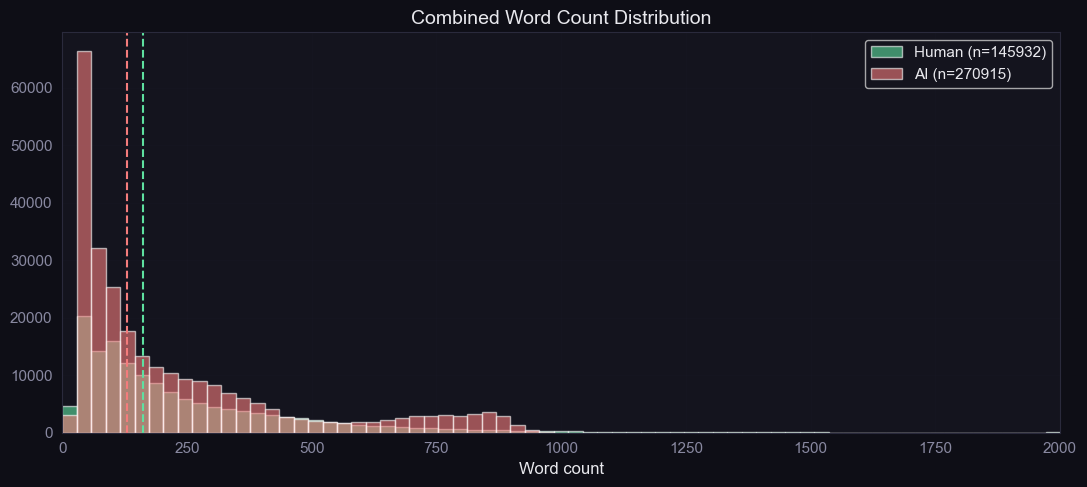

In [173]:
fig, ax = plt.subplots(figsize=(11, 5))
XCLIP = 2000
h = combined.loc[combined['label']==0,'word_count'].clip(upper=XCLIP)
a = combined.loc[combined['label']==1,'word_count'].clip(upper=XCLIP)
bins = np.linspace(0, XCLIP, 70)
ax.hist(h, bins=bins, color=GREEN, alpha=0.6, label="Human (n=" + str(len(h)) + ")")
ax.hist(a, bins=bins, color=CORAL, alpha=0.6, label="AI (n=" + str(len(a)) + ")")
ax.axvline(h.median(), color=GREEN, ls='--')
ax.axvline(a.median(), color=CORAL, ls='--')
ax.set_xlim(0, XCLIP)
ax.set_xlabel("Word count")
ax.set_title("Combined Word Count Distribution")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
savefig("combined_word_count_distribution.png")
plt.show()


## Section 11. Simpan Hasil

In [174]:
cols_daigt = [c for c in ['text','label','source','prompt_name'] if c in daigt_clean.columns]
cols_mage  = [c for c in ['text','label','source']                  if c in mage_clean.columns]

daigt_out = daigt_clean[cols_daigt].copy()
mage_out  = mage_clean[cols_mage].copy()
daigt_out['dataset'] = 'daigt_v2'
mage_out['dataset']  = 'mage'

daigt_out.to_csv("../data/processed/daigt_v2_clean.csv", index=False)
mage_out.to_csv("../data/processed/mage_clean.csv", index=False)

all_data = pd.concat([daigt_out, mage_out], ignore_index=True)
all_data.to_csv("../data/processed/combined_clean.csv", index=False)

print("Saved:")
print(" daigt_v2_clean.csv :", len(daigt_out))
print(" mage_clean.csv     :", len(mage_out))
print(" combined_clean.csv :", len(all_data))


Saved:
 daigt_v2_clean.csv : 44866
 mage_clean.csv     : 371981
 combined_clean.csv : 416847


## Section 12. Key Findings

**Ukuran data.** DAIGT v2 sekitar 44 ribu essay, MAGE setelah train+test sekitar 360 ribu teks. Setelah cleaning, gabungan tetap ratusan ribu sampel, cukup banyak buat training.

**Konvensi label.** DAIGT v2 udah pakai 0 = human, 1 = AI. MAGE awalnya kebalikan, jadi di-invert. Setelah di-spot-check ke source yang ada kata 'human'-nya, label-nya udah bener.

**Class imbalance (perlu dicatat).** Di gabungan, sekitar 35% human dan 65% AI. Ratio AI ke human kira-kira 1.8x. Buat training nanti kita harus pakai stratified split, plus salah satu dari `class_weight='balanced'` atau undersampling, biar model nggak bias ke AI. Alternatif lain pakai DAIGT v2 sendiri yang lebih balanced.

**Domain mismatch (yang menarik).** DAIGT v2 itu domain essay mahasiswa, panjang, formal. MAGE domain media sosial dan QA, pendek, casual. Median word count beda jauh. Risiko: model bisa belajar shortcut bahwa 'teks pendek = MAGE = mostly AI', bukan ciri tulisan AI yang asli. Solusinya bisa: pakai DAIGT v2 sebagai dataset utama buat ngajarin gaya, dan MAGE buat augmentasi dengan sampling yang nyamain panjang teks.

**Panjang teks.** Tulisan human di MAGE biasanya lebih variatif (ada yang pendek banget, ada yang panjang), sementara AI cenderung di range yang lebih konsisten. Di DAIGT v2, dua-duanya panjang-panjang karena emang format essay.

**Kualitas data.** Cleaning buang null, kosong, duplikat, teks di luar rentang 20 sampai 5000 kata. Cross-dataset duplicate juga dicek. Persentase yang dibuang relatif kecil dibanding total dan balance kelas nggak berubah signifikan.

**Sumber MAGE.** Banyak banget LLM yang dipakai di MAGE (lihat plot source distribution), ini bagus buat generalisasi model deteksi.

### Next Step
- Notebook `02_features.ipynb` buat ekstrak fitur stylometric
- Cek fitur mana yang paling diskriminatif
- Putuskan: pakai DAIGT only, MAGE only, atau combined dengan strategi sampling tertentu
